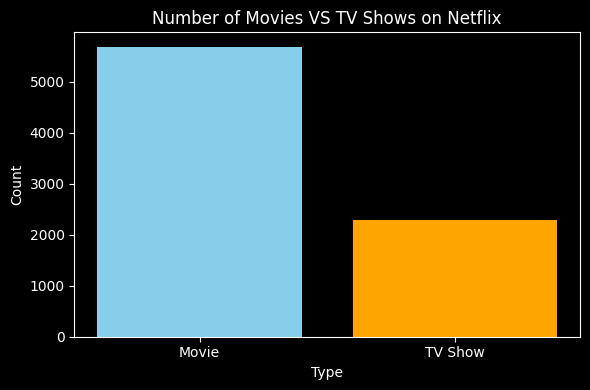

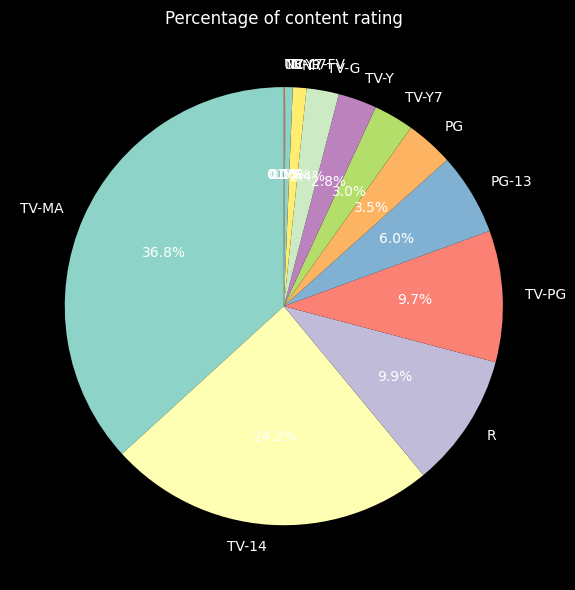

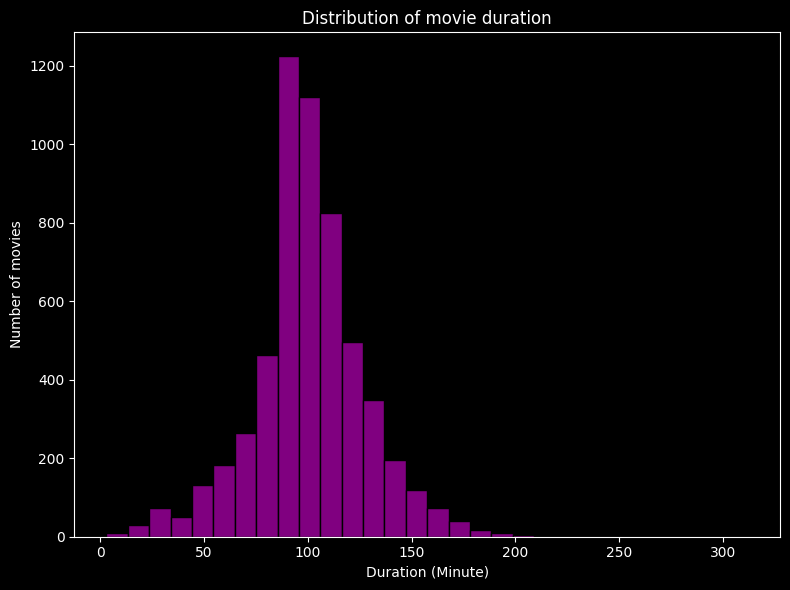

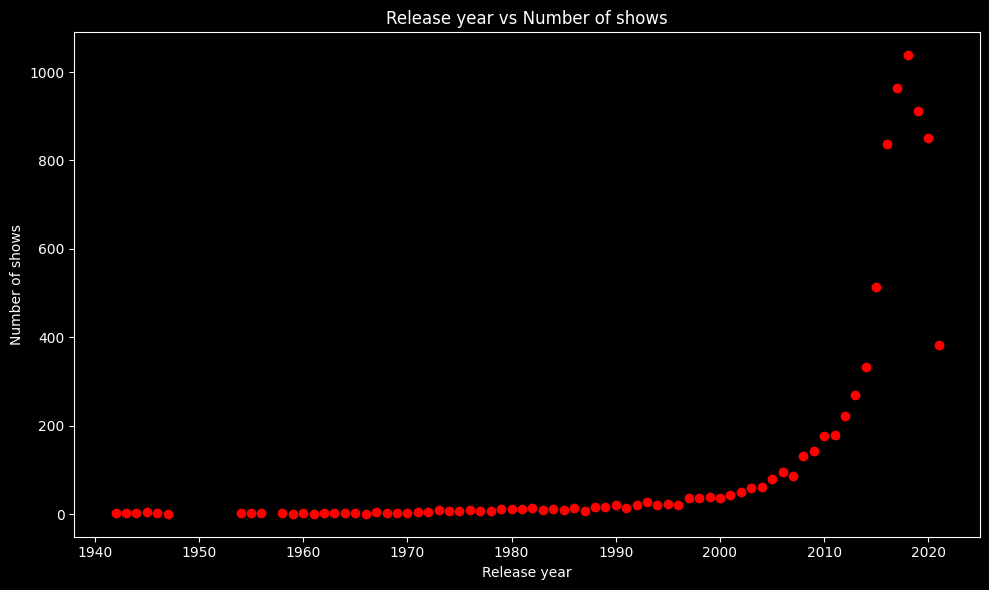

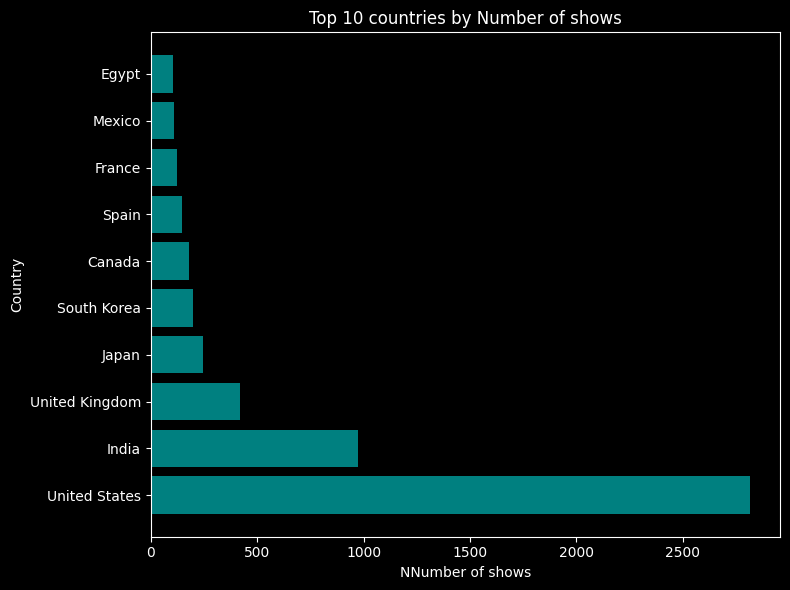

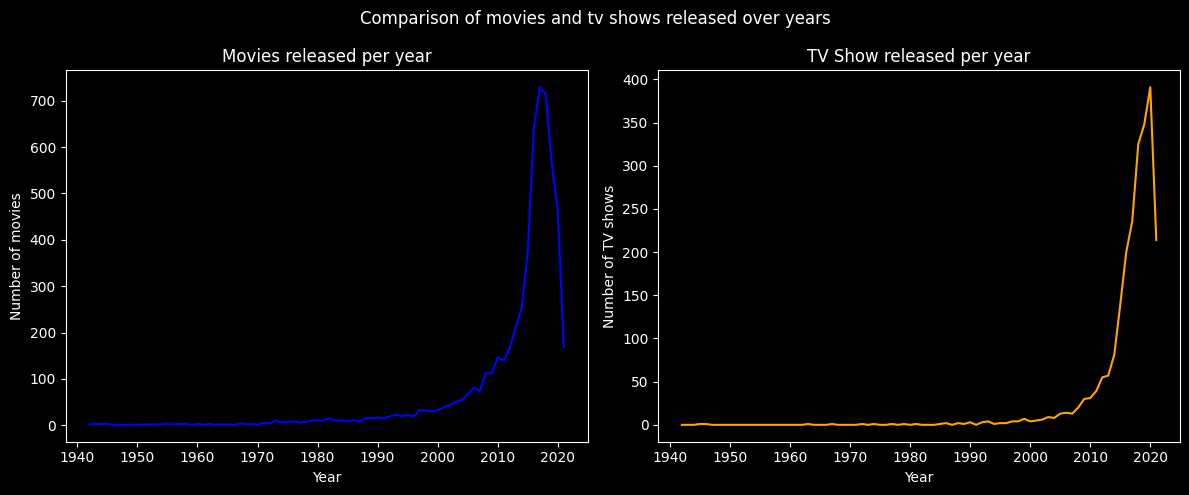

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# load data
df = pd.read_csv('netflix_titles.csv')

# clean data
df = df.dropna(subset = ['type', 'release_year', 'rating', 'country', 'duration'])

type_counts = df['type'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(type_counts.index, type_counts.values, color=['skyblue', 'orange'])
plt.title('Number of Movies VS TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()

rating_counts = df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts, labels=rating_counts.index, autopct = '%1.1f%%', startangle = 90)
plt.title('Percentage of content rating')
plt.tight_layout()
plt.savefig('content_rating_pie.png')
plt.show()

movie_df = df[df['type'] == 'Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace(' min', '').astype(int)
plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_int'], bins = 30, color='purple', edgecolor='black')
plt.title('Distribution of movie duration')
plt.xlabel('Duration (Minute)')
plt.ylabel('Number of movies')
plt.tight_layout()
plt.savefig('movies_duration_hist.png')
plt.show()


release_count = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.scatter(release_count.index, release_count.values, color = 'red')
plt.title('Release year vs Number of shows')
plt.xlabel('Release year')
plt.ylabel('Number of shows')
plt.tight_layout()
plt.savefig('release_year_scatter.png')
plt.show()


country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(8, 6))
plt.barh(country_counts.index, country_counts.values, color='teal')
plt.title('Top 10 countries by Number of shows')
plt.xlabel('NNumber of shows')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top10_countries.png')
plt.show()


content_by_year = df.groupby(['release_year', 'type']).size().unstack().fillna(0)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# first subplot:movie
ax[0].plot(content_by_year.index, content_by_year['Movie'], color = 'blue')
ax[0].set_title('Movies released per year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of movies')

# second subplot:tvshows
ax[1].plot(content_by_year.index, content_by_year['TV Show'], color = 'orange')
ax[1].set_title('TV Show released per year')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Number of TV shows')

fig.suptitle('Comparison of movies and tv shows released over years')
plt.tight_layout()
plt.savefig('movies_tv_shows_comparison.png')
plt.show()